In [50]:
import qiskit
from qiskit_aer import AerSimulator

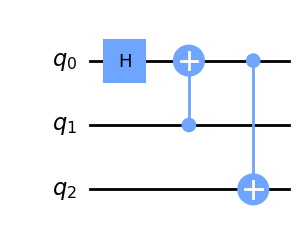

In [51]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

# Create a circuit with a register of three qubits
circ = QuantumCircuit(3)
# H gate on qubit 0, putting this qubit in a superposition of |0> + |1>.
circ.h(0)
# A CX (CNOT) gate on control qubit 1 and target qubit 0 generating a Bell state.
circ.cx(1, 0)
# CX (CNOT) gate on control qubit 0 and target qubit 2 resulting in a GHZ state.
circ.cx(0, 2)
# Draw the circuit
circ.draw('mpl')

In [52]:
from qiskit.quantum_info import Statevector

# Set the initial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**3)

# Evolve the state by the quantum circuit
state = state.evolve(circ)

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

In [53]:
from qiskit.visualization import array_to_latex

#Alternative way of representing in latex
array_to_latex(state)

<IPython.core.display.Latex object>

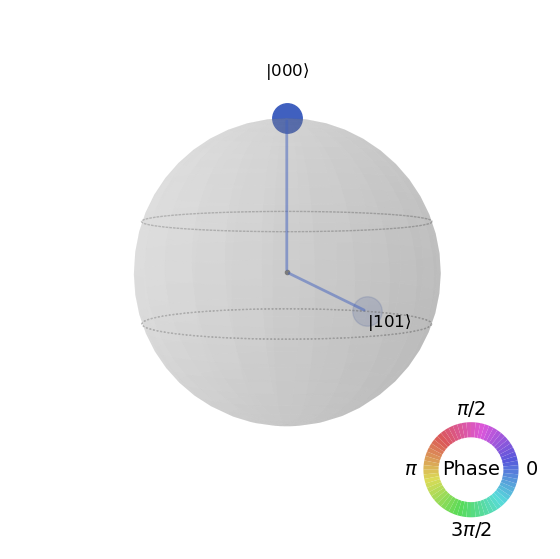

In [54]:
state.draw('qsphere')

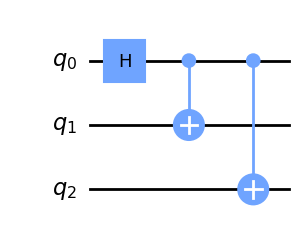

In [55]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

# Create a circuit with a register of three qubits
circ = QuantumCircuit(3)
# H gate on qubit 0, putting this qubit in a superposition of |0> + |1>.
circ.h(0)
# A CX (CNOT) gate on control qubit 0 and target qubit 1 generating a Bell state.
circ.cx(0, 1)
# CX (CNOT) gate on control qubit 0 and target qubit 2 resulting in a GHZ state.
circ.cx(0, 2)
# Draw the circuit
circ.draw('mpl')

In [56]:
from qiskit.quantum_info import Statevector

# Set the initial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**4)

# Evolve the state by the quantum circuit
state = state.evolve(circ)

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

In [57]:
from qiskit.visualization import array_to_latex

#Alternative way of representing in latex
array_to_latex(state)

<IPython.core.display.Latex object>

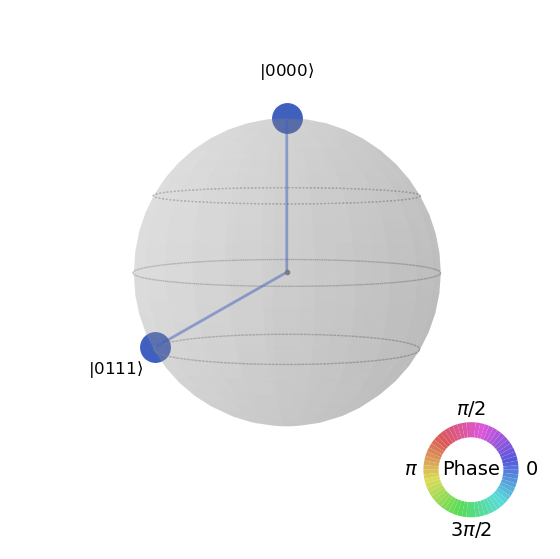

In [58]:
state.draw('qsphere')

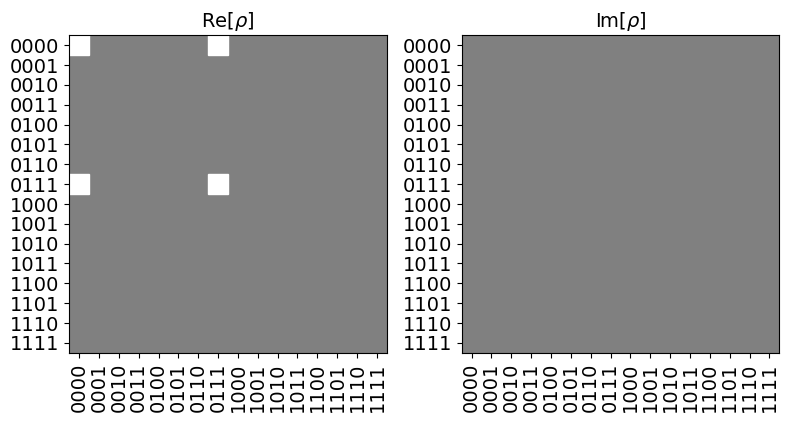

In [59]:
state.draw('hinton')

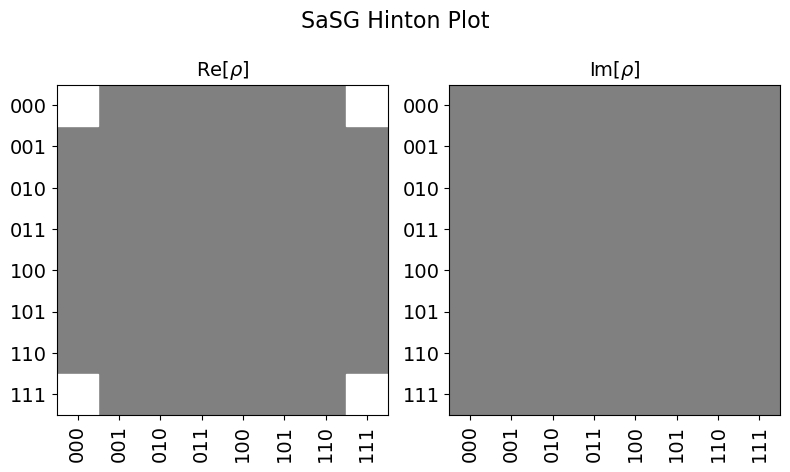

In [75]:
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_hinton

state = DensityMatrix(circ)
plot_state_hinton(state, title="SaSG Hinton Plot")

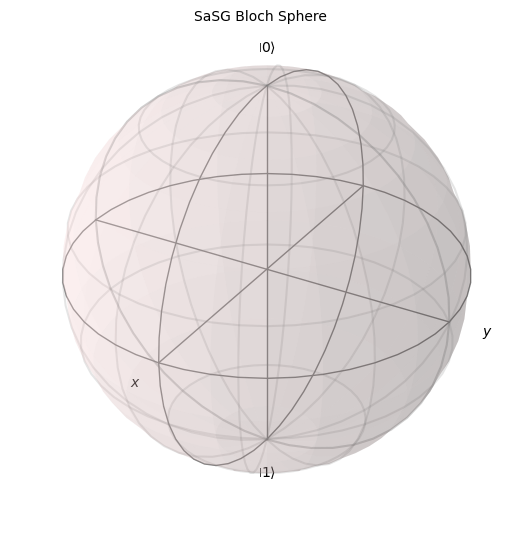

In [61]:
from qiskit.visualization import plot_bloch_vector
plot_bloch_vector([0,0,0], title="SaSG Bloch Sphere")

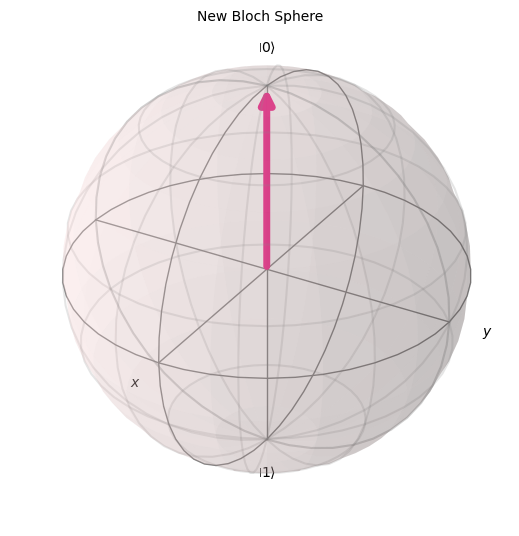

In [62]:
plot_bloch_vector([0,0,1], title="New Bloch Sphere")

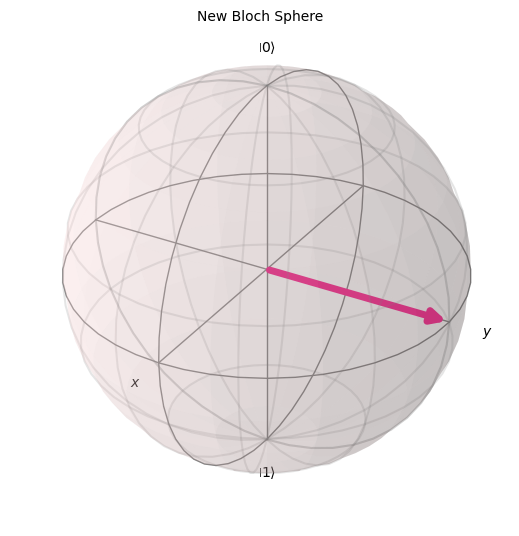

In [63]:
plot_bloch_vector([0,1,0], title="New Bloch Sphere")

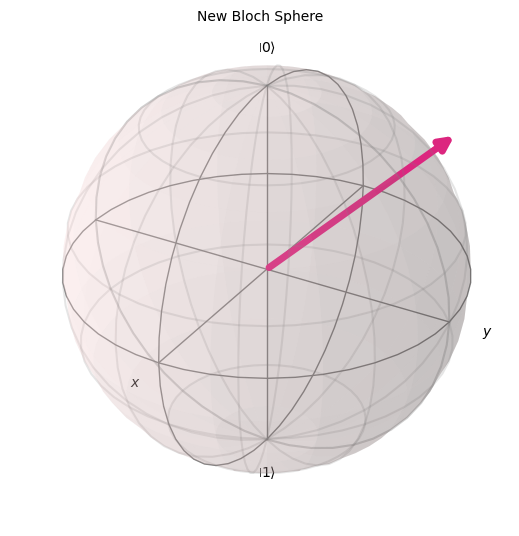

In [64]:
plot_bloch_vector([0,1,1], title="New Bloch Sphere")

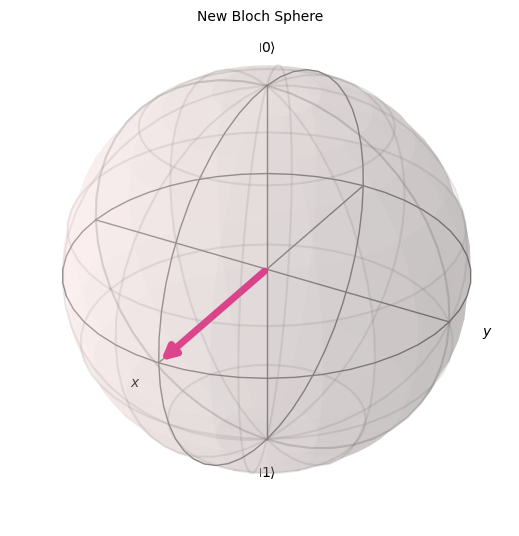

In [65]:
plot_bloch_vector([1,0,0], title="New Bloch Sphere")

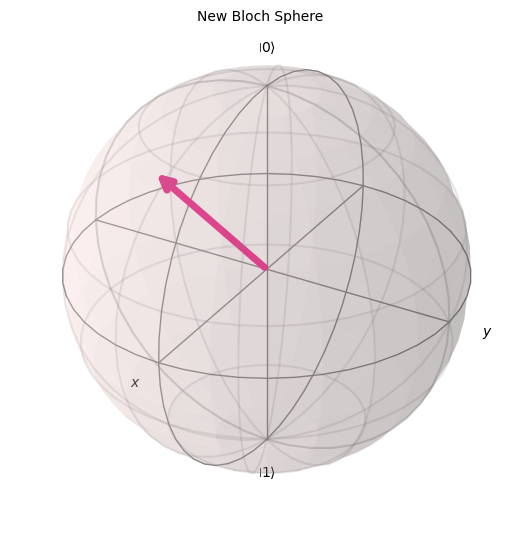

In [66]:
plot_bloch_vector([1,0,1], title="New Bloch Sphere")

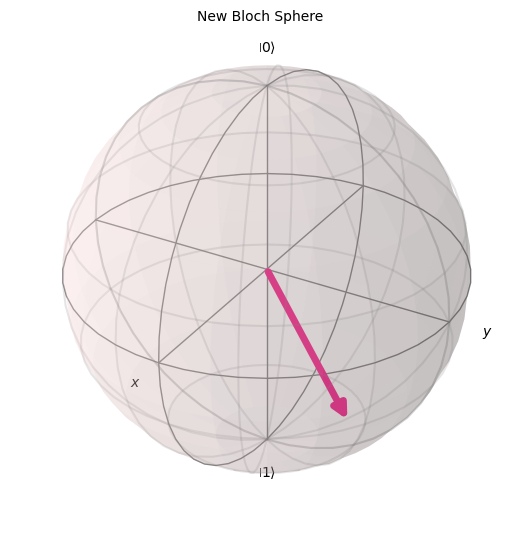

In [67]:
plot_bloch_vector([1,1,0], title="New Bloch Sphere")

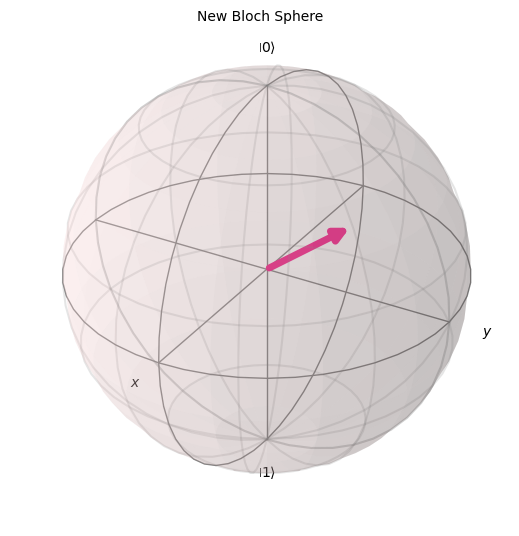

In [68]:
plot_bloch_vector([1,1,1], title="New Bloch Sphere")

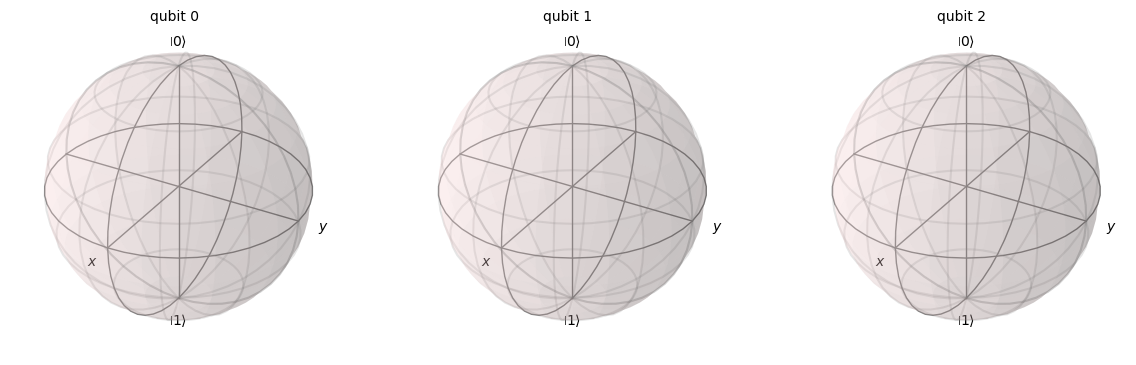

In [69]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

state = Statevector(circ)
plot_bloch_multivector(state)

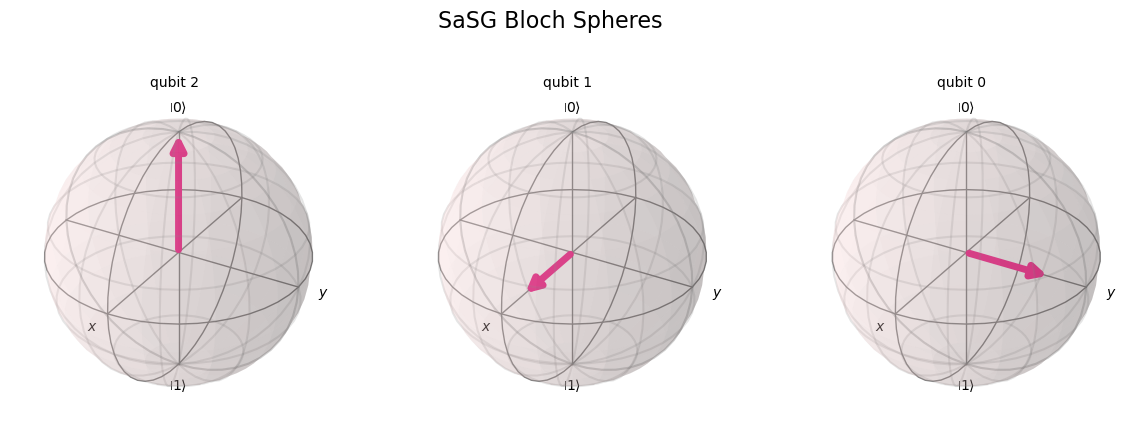

In [70]:
# You can reverse the order of the qubits.

from qiskit.quantum_info import DensityMatrix

qc = QuantumCircuit(3)
qc.h([0, 1])
qc.t(1)
qc.s(0)
qc.cx(0,1)

matrix = DensityMatrix(qc)
plot_bloch_multivector(matrix, title='SaSG Bloch Spheres', reverse_bits=True)

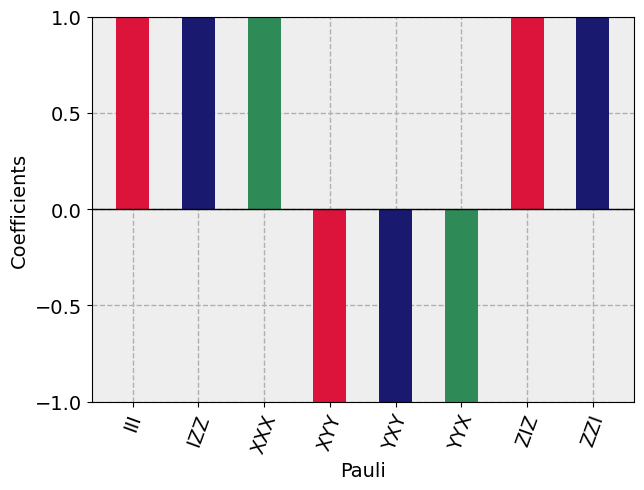

In [71]:
import numpy as np
from qiskit.quantum_info import DensityMatrix
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_paulivec

#Plot the Pauli-vector representation of a quantum state as bar graph.

matrix = DensityMatrix(circ)
plot_state_paulivec(matrix, color=['crimson', 'midnightblue', 'seagreen'])

In [72]:
from qiskit.quantum_info import Operator

U = Operator(circ)

# Show the results
U.data

array([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.70710678+0.j, -0.70710678+0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
         0.70710678+0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.70710678+0.j,  0.70710678+0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
        -0.70710678+0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.      

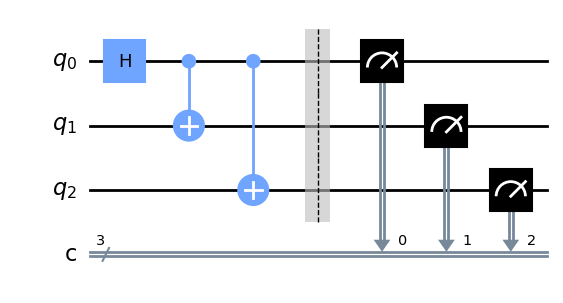

In [77]:
# Create a Quantum Circuit
meas = QuantumCircuit(3, 3)
meas.barrier(range(3))
# map the quantum measurement to the classical bits
meas.measure(range(3), range(3))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circ, range(3), front=True)

#drawing the circuit
qc.draw('mpl')

In [83]:
# Adding the transpiler to reduce the circuit to QASM instructions
# supported by the backend
from qiskit import transpile

# Use AerSimulator
from qiskit_aer import AerSimulator

backend = AerSimulator()

# First we have to transpile the quantum circuit
# to the low-level QASM instructions used by the
# backend
qc_compiled = transpile(qc, backend)

# Execute the circuit on the qasm simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job.
result_sim = job_sim.result()

In [85]:
counts = result_sim.get_counts(qc)
print(counts)

{'000': 543, '111': 481}


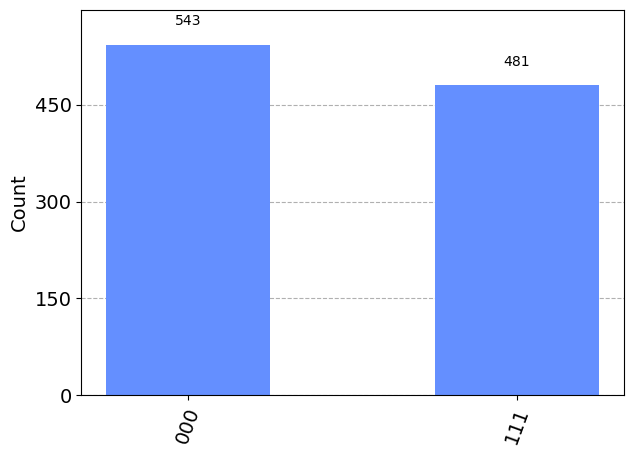

In [86]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

#Approximately 50 per cent of the time, the output bitstring is 000.
#Qiskit also provides a function plot_histogram, which allows you to view the outcomes.